In [114]:
import pandas as pd 
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt 
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
import statsmodels.api as sm
import pmdarima as pm
import matplotlib.dates as mdates
import matplotlib as mpl
from cycler import cycler

mpl.rcParams['axes.prop_cycle'] = cycler(color=['teal', 'maroon', 'steelblue', '#3EB489', '#6B8E23'])


In [115]:
# metrics that will be used later

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def mae(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred))) 


def ljung_box_test(residuals, is_seasonal, period):
    
    if is_seasonal:
        lb_df = acorr_ljungbox(residuals, period=period)
    else:
        max_lag = min([10, len(residuals)/5])
        
        lb_df = acorr_ljungbox(residuals, np.arange(1, max_lag+1, 1))

    fig, ax = plt.subplots()
    ax.plot(lb_df['lb_pvalue'], 'b-', label='p-values')
    ax.hlines(y=0.05, xmin=1, xmax=len(lb_df), color='black')
    plt.tight_layout()
    
    if all(pvalue > 0.05 for pvalue in lb_df['lb_pvalue']):
        print('All values are above 0.05. We fail to reject the null hypothesis. The residuals are uncorrelated')
    else:
        print('At least one p-value is smaller than 0.05')

In [116]:
df = pd.read_csv('/home/uplong/Documents/DSU-analytics-comp-2026/data/grouped_by_year_month.csv', parse_dates=['Date'])
df = df.set_index('Date')
df = df.drop(columns=['unique_entry_per_day', 'total_admittances'])

In [117]:
def normalize(df): 
    df['total_enc_norm'] = df.total_encounters / df.index.days_in_month  # normalize with days in month to acount for february for example
    df = df.drop('total_encounters', axis=1)
    return df
    
def revert(df):
    df['total_encounters'] = df.total_enc_norm * df.index.days_in_month
    df = df.drop('total_enc_norm', axis=1)
    return df

In [118]:
df = normalize(df)

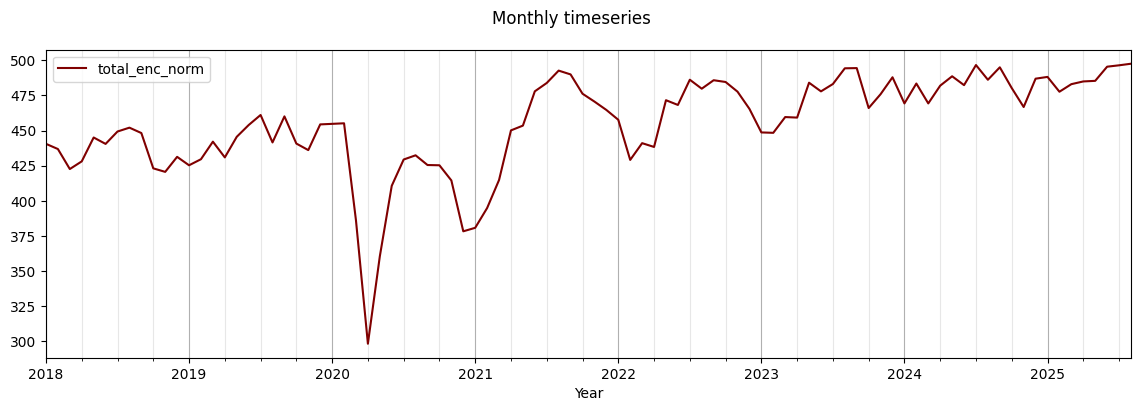

In [119]:
df.plot(
    kind='line',
    figsize=(14,4),
    color='maroon',
)
plt.grid(axis='x')
plt.grid(which='minor', axis='x', alpha=0.3)
plt.legend()
plt.suptitle('Monthly timeseries')
plt.xlabel('Year')
plt.show()

In [120]:
# Check stationarity (w/o correction)
ad_index = adfuller(df['2021':])[0] # we ignore the outlier
p_val = adfuller(df['2021':])[1]

print(f'Adfuller Index: {ad_index}')
print(f'p-val: {p_val}')
print(f'Stationarity: {p_val<=5e-2}')


Adfuller Index: -0.31365154249733285
p-val: 0.9235484881242906
Stationarity: False


In [121]:
# Make stationary
diff = np.diff(df.total_enc_norm, n=1)

ad_index = adfuller(diff[36:])[0]
p_val = adfuller(diff[36:])[1]

print(f'Adfuller Index: {ad_index}')
print(f'p-val: {p_val}')
print(f'Stationarity: {p_val<=5e-2}')

Adfuller Index: -6.747466429323355
p-val: 3.0095541151060984e-09
Stationarity: True


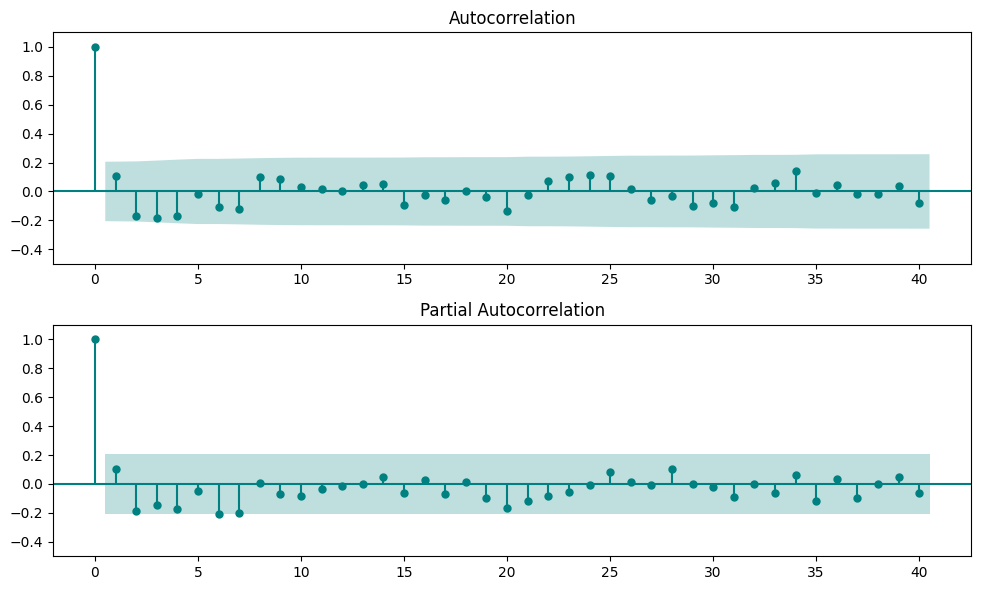

In [122]:
# Check ACF and PACF
LAGS = 40

fig, ax = plt.subplots(2,1, figsize=(10,6))

plot_acf(diff, lags=LAGS, ax=ax[0])
# ax[0].vlines(list(range(0,LAGS,12)), ymin=-.5, ymax=1.1, color='black', linestyle='--')
ax[0].set_ylim(-.5,1.1)

plot_pacf(diff, lags=LAGS, ax=ax[1])
# ax[1].vlines(list(range(0,LAGS,12)), ymin=-.5, ymax=1.1, color='black', linestyle='--')
ax[1].set_ylim(-.5,1.1)

plt.tight_layout()
plt.show()

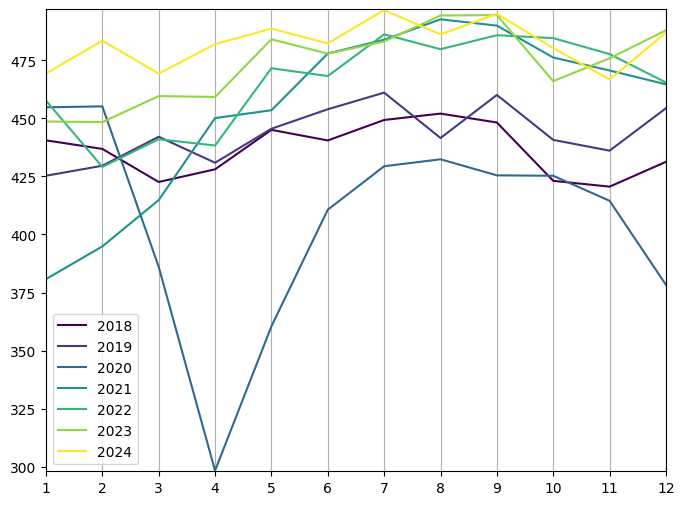

In [123]:
y_min_lim = np.int16(df.min()) 
y_max_lim = np.int16(df.max())

plt.figure(figsize=(8, 6))

cmap = plt.cm.viridis
years = range(2018, 2025)

for i, year in enumerate(years):
    plt.plot(
        df[df.index.year == year].to_numpy(),
        label=str(year),
        color=cmap(i / (len(years) - 1))
    )

plt.xlim(0,11)
plt.xticks(list(range(0,12,1)), labels=list(range(1,13,1)))
plt.ylim(y_min_lim, y_max_lim)
plt.legend()
plt.grid(axis='x')
plt.show()

no seasonal pattern

In [124]:
# smoothen 2020 
mean_19_21 = (df.loc['2019-03':'2020-02', 'total_enc_norm'].to_numpy() + df.loc['2021-03':'2022-02', 'total_enc_norm'].to_numpy()) / 2
df['total_enc_norm_c'] = df['total_enc_norm'].astype(float)
df.loc['2020-03':'2021-02', 'total_enc_norm_c'] = mean_19_21

train = df[df.index.year < 2025]
test = df[df.index.year >= 2025]

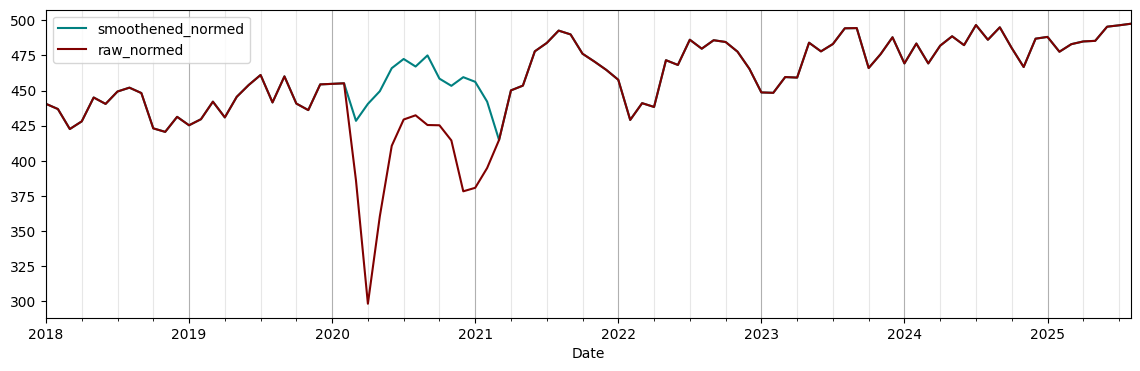

In [125]:
df.total_enc_norm_c.plot(figsize=(14,4), label='smoothened_normed')
df.total_enc_norm.plot(figsize=(14,4), label='raw_normed')

plt.grid(which='major', axis='x')
plt.grid(which='minor', axis='x', alpha=0.3)

plt.legend()
plt.show()

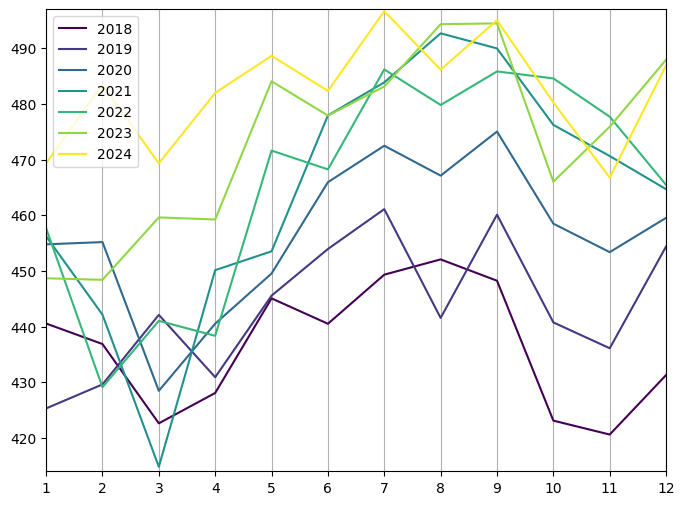

In [126]:
y_min_lim = np.int16(df.total_enc_norm_c.min()) 
y_max_lim = np.int16(df.total_enc_norm_c.max())

plt.figure(figsize=(8, 6))

cmap = plt.cm.viridis
years = range(2018, 2025)

for i, year in enumerate(years):
    plt.plot(
        df.total_enc_norm_c[df.index.year == year].to_numpy(),
        label=str(year),
        color=cmap(i / (len(years) - 1))
    )

plt.xlim(0,11)
plt.xticks(list(range(0,12,1)), labels=list(range(1,13,1)))
plt.ylim(y_min_lim, y_max_lim)
plt.legend()
plt.grid(axis='x')
plt.show()

with closer inspection it seems that smoothening the 2020 helps creating a seasonal pattern, but it's not so clear

In [127]:
diff_c = np.diff(df.total_enc_norm_c, 1)

ad_index = adfuller(diff_c)[0]
p_val = adfuller(diff_c)[1]

print(f'Adfuller Index: {ad_index}')
print(f'p-val: {p_val}')
print(f'Stationarity: {p_val<=5e-2}')

Adfuller Index: -7.798532459322071
p-val: 7.602231148711275e-12
Stationarity: True


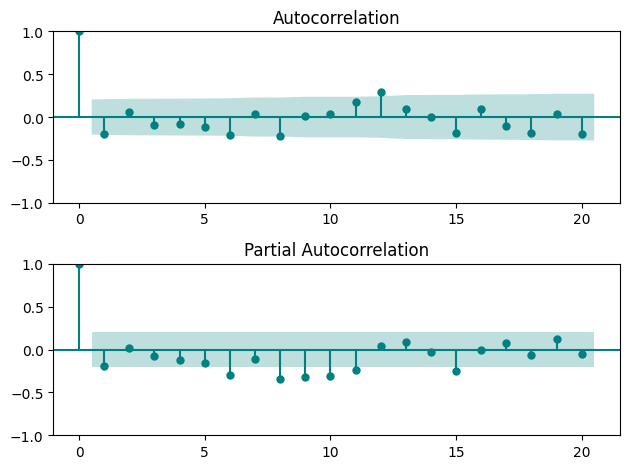

In [128]:
fig, ax = plt.subplots(2,1)
plot_acf(diff_c, ax=ax[0])
plot_pacf(diff_c, ax=ax[1])
plt.tight_layout()
plt.show()

the acf shows there is indeed a possible seasonality at 12

# Models

In [129]:
model = pm.auto_arima(
    y=train['total_enc_norm'],
    seasonal=True,
    m=12,
    error_action='ignore',
    suppress_warnings=True,
)

In [130]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   84
Model:               SARIMAX(0, 1, 0)   Log Likelihood                -367.734
Date:                Fri, 13 Feb 2026   AIC                            737.467
Time:                        19:12:54   BIC                            739.886
Sample:                    01-01-2018   HQIC                           738.439
                         - 12-01-2024                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2       412.9045     34.387     12.007      0.000     345.506     480.303
===================================================================================
Ljung-Box (L1) (Q):                   0.99   Jarque-Bera (JB):               101.47
Prob(Q):                              0.32   Prob(JB):                         0.00
Heteroskedasticity (H):               0.24   Skew:                            -0.96
Prob(H) (two-sided):                  0.00   Kurtosis:                         8.06
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

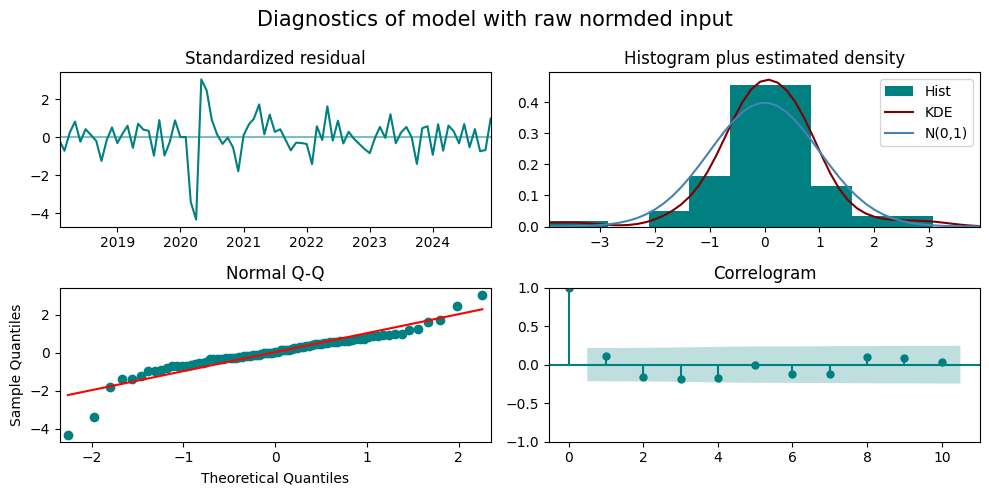

In [131]:
model.plot_diagnostics(figsize=(10,5))
plt.suptitle('Diagnostics of model with raw normded input', fontsize=15)
plt.tight_layout()
plt.show()

In [132]:
preds = model.predict(n_periods=8)

All values are above 0.05. We fail to reject the null hypothesis. The residuals are uncorrelated


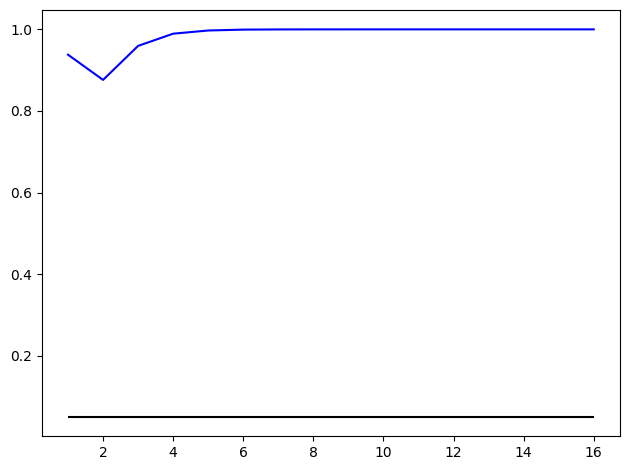

In [133]:
ljung_box_test(model.resid(), is_seasonal=True, period=12)

In [134]:
MAPE = mape(test['total_enc_norm'].to_numpy().flatten(), preds.to_numpy())
MAE = mae(test['total_enc_norm'].to_numpy().flatten(), preds.to_numpy())

In [135]:
df['is_2020_shock'] = 0
df.loc['2020-03-01':'2021-02-01', 'is_2020_shock'] = 1

train_exog = df.loc[train.index, 'is_2020_shock']
test_exog = df.loc[test.index, 'is_2020_shock']



model_with_exog = pm.auto_arima(
    y=train['total_enc_norm'],
    X=train_exog.to_numpy().reshape(-1,1),
    seasonal=True,
    m=12,
    error_action='ignore',
    suppress_warnings=True,
)


In [136]:
model_with_exog.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   84
Model:               SARIMAX(0, 1, 0)   Log Likelihood                -362.630
Date:                Fri, 13 Feb 2026   AIC                            729.260
Time:                        19:12:55   BIC                            734.098
Sample:                    01-01-2018   HQIC                           731.204
                         - 12-01-2024                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1           -44.5286     10.503     -4.240      0.000     -65.113     -23.944
sigma2       365.0741     29.958     12.186      0.000     306.358     423.790
===================================================================================
Ljung-Box (L1) (Q):                   0.55   Jarque-Bera (JB):               100.63
Prob(Q):                              0.46   Prob(JB):                         0.00
Heteroskedasticity (H):               0.30   Skew:                            -0.64
Prob(H) (two-sided):                  0.00   Kurtosis:                         8.24
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

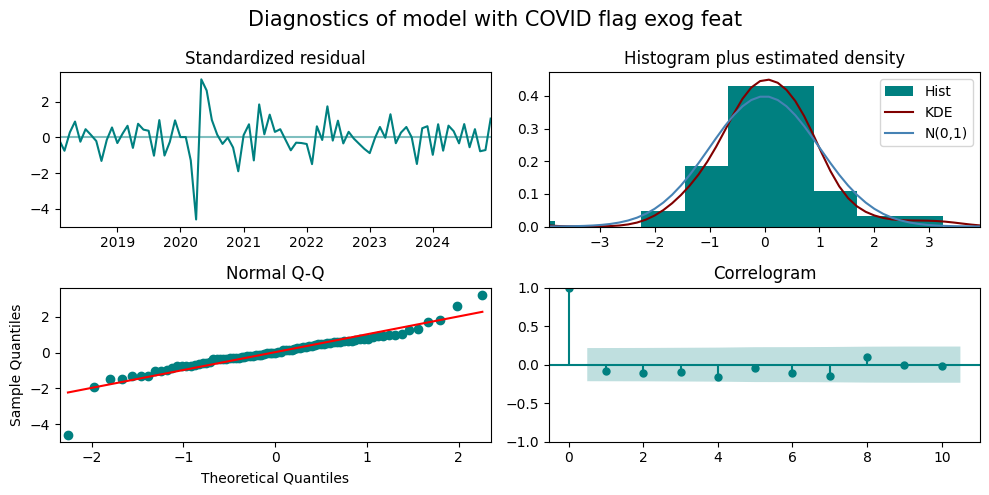

In [137]:
model_with_exog.plot_diagnostics(figsize=(10,5))
plt.suptitle('Diagnostics of model with COVID flag exog feat', fontsize=15)
plt.tight_layout()
plt.show()

In [138]:
preds_x = model_with_exog.predict(n_periods=8, X=np.zeros((8,1)))
preds_x.to_numpy()
MAPE_x = mape(test['total_enc_norm'].to_numpy().flatten(), preds_x.to_numpy())
MAE_x = mae(test['total_enc_norm'].to_numpy().flatten(), preds_x.to_numpy())


In [139]:
model_with_corrected = pm.auto_arima(
    y=train['total_enc_norm_c'],
    seasonal=True,
    m=12,
    error_action='ignore',
    suppress_warnings=True,
)
model_with_corrected.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                                   y   No. Observations:                   84
Model:             SARIMAX(1, 1, 1)x(1, 0, [], 12)   Log Likelihood                -320.160
Date:                             Fri, 13 Feb 2026   AIC                            648.320
Time:                                     19:13:00   BIC                            657.995
Sample:                                 01-01-2018   HQIC                           652.207
                                      - 12-01-2024                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3712      0.131      2.829      0.005       0.114       0.628
ma.L1         -0.9033      0.066    -13.609      0.000      -1.033      -0.773
ar.S.L12       0.5218      0.113      4.631      0.000       0.301       0.743
sigma2       124.2860     26.083      4.765      0.000      73.164     175.408
===================================================================================
Ljung-Box (L1) (Q):                   0.63   Jarque-Bera (JB):                 5.47
Prob(Q):                              0.43   Prob(JB):                         0.06
Heteroskedasticity (H):               0.86   Skew:                            -0.62
Prob(H) (two-sided):                  0.69   Kurtosis:                         2.84
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

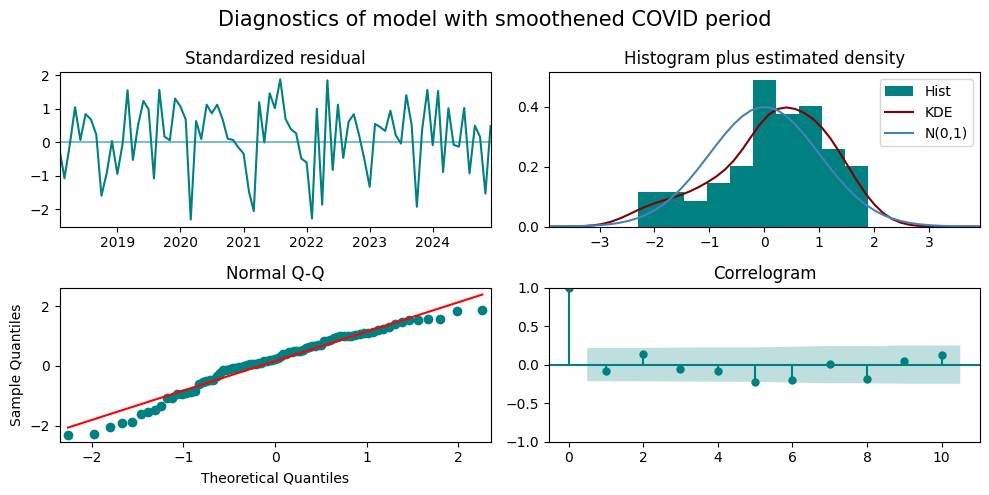

In [140]:
model_with_corrected.plot_diagnostics(figsize=(10,5))
plt.suptitle('Diagnostics of model with smoothened COVID period', fontsize=15)
plt.tight_layout()
plt.show()

In [141]:
preds_c = model_with_corrected.predict(n_periods=8)
MAPE_c = mape(test['total_enc_norm_c'].to_numpy().flatten(), preds_c.to_numpy())
MAE_c = mae(test['total_enc_norm_c'].to_numpy().flatten(), preds_c.to_numpy())

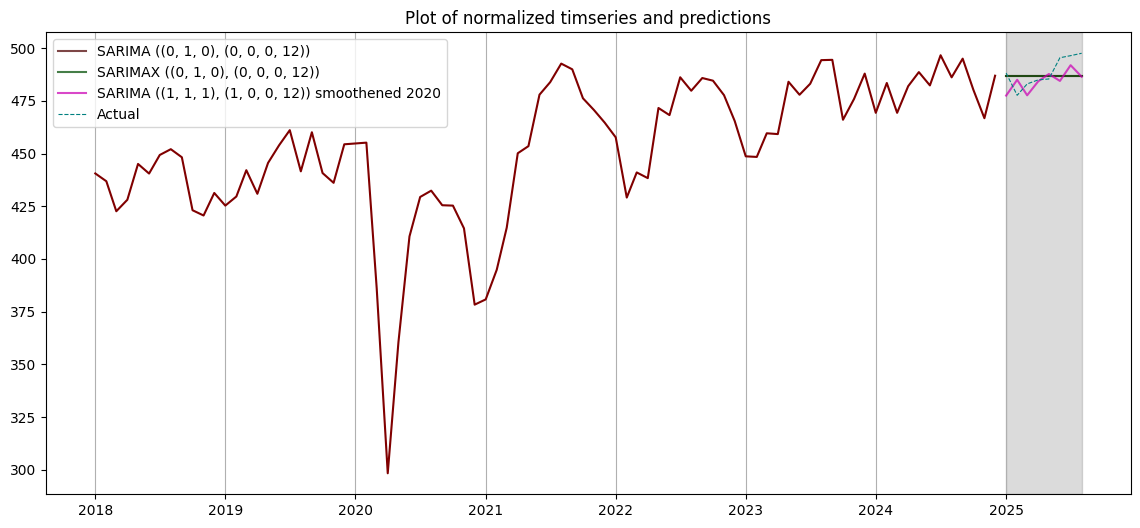

In [142]:
plt.figure(figsize=(14,6))
plt.plot(train['total_enc_norm'], color='maroon')
plt.plot(preds, color="#4D0000B8", label=f'SARIMA {model.get_params()['order'], model.get_params()['seasonal_order']}')
plt.plot(preds_x, color="#004D03B9",label=f'SARIMAX {model_with_exog.get_params()['order'], model_with_exog.get_params()['seasonal_order']}')
plt.plot(preds_c, color="#CB01B4B8", label=f'SARIMA {model_with_corrected.get_params()['order'], model_with_corrected.get_params()['seasonal_order']} smoothened 2020')

plt.plot(test['total_enc_norm'], linestyle='--', linewidth=0.8, color='teal', label='Actual')
plt.axvspan(test.index.min(), test.index.max(), color="#4D4D4D32", alpha=0.2)
plt.grid(axis='x')
# plt.xlim(19710)
# plt.ylim(11111)
plt.legend()
plt.title('Plot of normalized timseries and predictions')
plt.show()

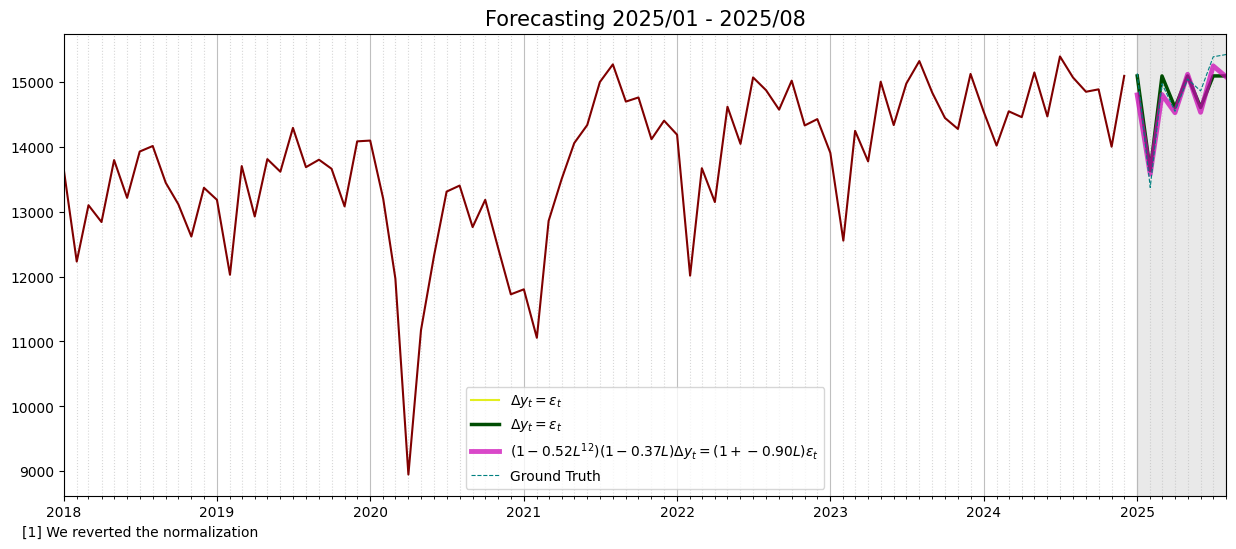

In [145]:
plt.figure(figsize=(15,6))
ax = plt.gca()

plt.plot(
    revert(train['total_enc_norm'].to_frame()),
    color='maroon'
)

plt.plot(
    revert(pd.DataFrame(preds, columns=['total_enc_norm'])),
    color="#E0EC00DF",
    # label=model.summary().tables[0].data[1][1]
    label = r'$\Delta y_t = \epsilon_t$'
    
)

plt.plot(
    revert(pd.DataFrame(preds_x, columns=['total_enc_norm'])),
    color="#004D03FF",
    lw=2.5,
    # label=model_with_exog.summary().tables[0].data[1][1]
    label = r'$\Delta y_t = \epsilon_t$'
)

plt.plot(
    revert(pd.DataFrame(preds_c, columns=['total_enc_norm'])),
    color="#CB01B4B8",
    lw=3.5,
    # label=model_with_corrected.summary().tables[0].data[1][1] + '\nsmoothened 2020'
    label = r'$(1 - 0.52L^{12})(1 - 0.37L)\Delta y_t = (1 + -0.90L)\epsilon_t$'
)

plt.plot(
    revert(pd.DataFrame(test['total_enc_norm'])),
    ls='--',
    lw=0.8,
    color='teal',
    label='Ground Truth'
)

plt.axvspan(test.index.min(), test.index.max(), color="#6C6C6C00", alpha=0.15)

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_minor_locator(mdates.MonthLocator())
plt.grid(which='minor', axis='x', linestyle=':', alpha=0.5)
plt.grid(which='major', axis='x', linestyle='-', alpha=0.8)

# plt.xlim(20000)
# plt.ylim(11111)
plt.xlim(train.index.min(), test.index.max())
plt.legend()
plt.title('Forecasting 2025/01 - 2025/08', fontsize=15)
plt.text(x=train.index.min()-dt.timedelta(days=100) ,y=8000, s='[1] We reverted the normalization')
plt.show()

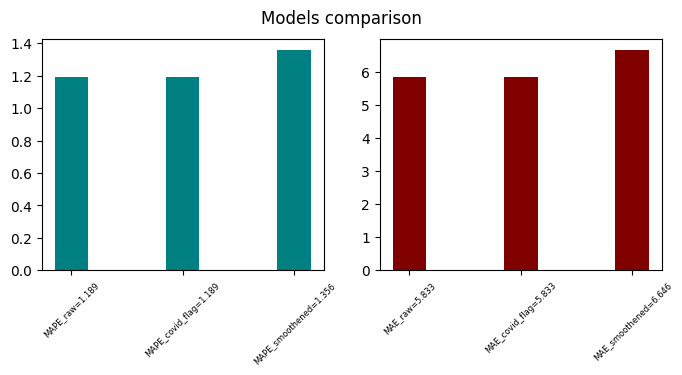

In [170]:
fig, ax = plt.subplots(1, 2, figsize=(8,3))

ax[0].bar([f'MAPE_raw={round(MAPE,3)}', f'MAPE_covid_flag={round(MAPE_x,3)}', f'MAPE_smoothened={round(MAPE_c,3)}'], [MAPE, MAPE_x, MAPE_c], width=0.3)
ax[1].bar([f'MAE_raw={round(MAE,3)}', f'MAE_covid_flag={round(MAE_x,3)}', f'MAE_smoothened={round(MAE_c,3)}'], [MAE, MAE_x, MAE_c], color='maroon', width=0.3)
plt.suptitle('Models comparison')
labels_mape = [
    f'MAPE_raw={round(MAPE,3)}',
    f'MAPE_covid_flag={round(MAPE_x,3)}',
    f'MAPE_smoothened={round(MAPE_c,3)}'
]

labels_mae = [
    f'MAE_raw={round(MAE,3)}',
    f'MAE_covid_flag={round(MAE_x,3)}',
    f'MAE_smoothened={round(MAE_c,3)}'
]

ax[0].set_xticks(range(3))
ax[0].set_xticklabels(labels_mape, rotation=45, fontsize=6)

ax[1].set_xticks(range(3))
ax[1].set_xticklabels(labels_mae, rotation=45, fontsize=6)
# plt.tight_layout()
plt.show()

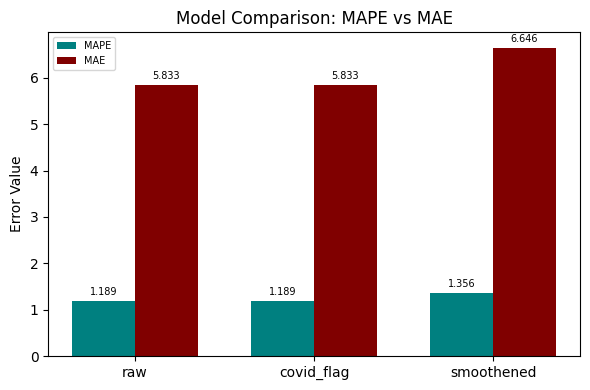

In [174]:
import matplotlib.pyplot as plt
import numpy as np

# Your values
models = ['raw', 'covid_flag', 'smoothened']
MAPE_values = [MAPE, MAPE_x, MAPE_c]
MAE_values = [MAE, MAE_x, MAE_c]

x = np.arange(len(models))  # label locations
width = 0.35  # width of bars

fig, ax = plt.subplots(figsize=(6,4))

# Plot MAPE bars
rects1 = ax.bar(x - width/2, MAPE_values, width, label='MAPE')

# Plot MAE bars
rects2 = ax.bar(x + width/2, MAE_values, width, label='MAE')

# Labels
ax.set_xticks(x)
ax.set_xticklabels([f'{m}' for m in models])
ax.set_ylabel('Error Value')
ax.set_title('Model Comparison: MAPE vs MAE')
ax.legend()

# Optional: add value labels on top of bars
for rects in [rects1, rects2]:
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0,3),
                    textcoords='offset points',
                    ha='center', va='bottom',
                    fontsize=7)
plt.legend(prop={"size":7})
plt.tight_layout()
plt.show()


In [33]:
# def get_math_formula(model_res):
#     p = model_res.params().to_dict()
#     # This is a simplified printer for a (1,1,1)x(1,0,0)12 model
#     formula = rf"(1 - {p.get('ar.S.L12', 0):.2f}L^{{12}})(1 - {p.get('ar.L1', 0):.2f}L)\Delta y_t = (1 + {p.get('ma.L1', 0):.2f}L)\epsilon_t"
#     return formula

# print(get_math_formula(model))